In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('image_data.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
label = df['label']

In [5]:
df2 = df.drop("label", axis = 1)

In [6]:
print(label.shape)
print(df2.shape)

(42000,)
(42000, 784)


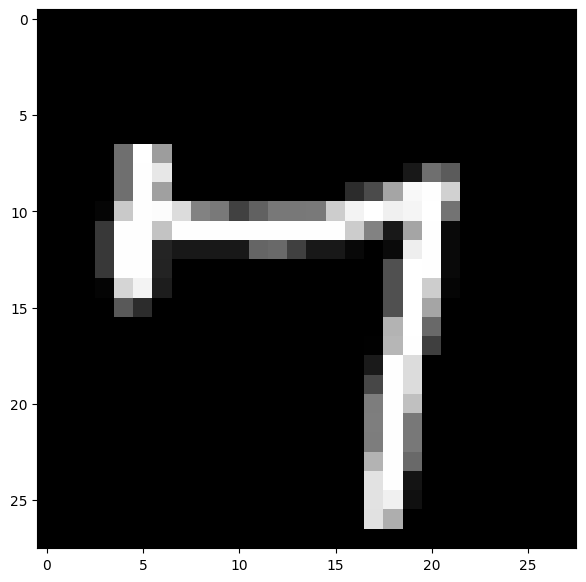

In [7]:
plt.figure(figsize=(7,7))
idx = 120

grid_data = df2.iloc[idx].values.reshape(28,28)
plt.imshow(grid_data, interpolation="none", cmap='gray')
plt.show()

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
scaler.fit(df2)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [10]:
x_stand = scaler.transform(df2)

In [11]:
pca = PCA(n_components=2)

In [12]:
x_embedded = pca.fit_transform(x_stand)

print(x_embedded.shape)

(42000, 2)


<Figure size 640x480 with 0 Axes>

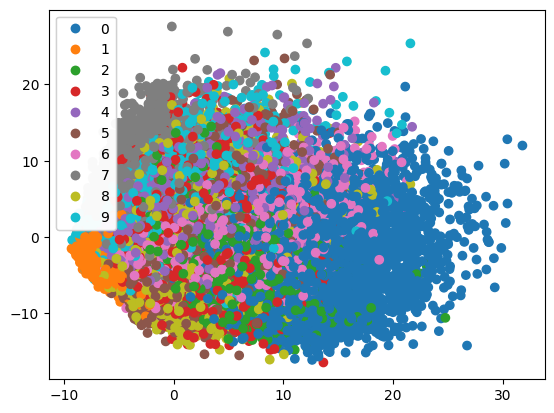

In [13]:
plt.set_cmap('tab10')

fig, ax = plt.subplots()
scatter = ax.scatter(x_embedded[:,0],x_embedded[:,1],c=label)

legend = ax.legend(*scatter.legend_elements(),loc="upper left")
ax.add_artist(legend)

plt.show()
plt.close()

In [14]:
pca.components_

array([[-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(2, 784))

In [15]:
from sklearn.manifold import TSNE
x_embedded = TSNE().fit_transform(df2)

<Figure size 640x480 with 0 Axes>

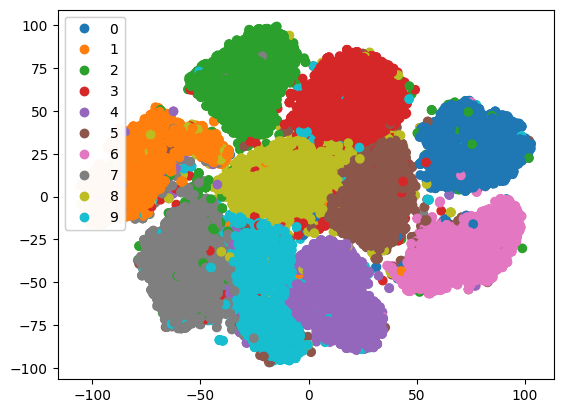

In [16]:
plt.set_cmap('tab10')

fig, ax = plt.subplots()
scatter = ax.scatter(x_embedded[:,0],x_embedded[:,1],c=label)

legend = ax.legend(*scatter.legend_elements(),loc="upper left")
ax.add_artist(legend)

plt.show()
plt.close()